In [1]:
import torch
import torch.nn.functional as F
import dnnlib
import legacy
import math
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import json
from sklearn.decomposition import PCA
import clip
import copy

In [2]:
def plot_tensor_images(images, titles=None, cols=4, figsize=4):
    if not isinstance(images, list):
        images = [images]

    n = len(images)
    rows = math.ceil(n / cols)

    plt.figure(figsize=(cols * figsize, rows * figsize))

    for i, img in enumerate(images):
        img = (img.permute(0, 2, 3, 1) * 127.5 + 128).clamp(0, 255).to(torch.uint8)
        pil_img = Image.fromarray(img[0].cpu().numpy())
        plt.subplot(rows, cols, i + 1)
        plt.imshow(pil_img)
        plt.axis("off")

        if titles and i < len(titles):
            plt.title(titles[i], fontsize=10)

    plt.tight_layout()
    plt.show()

In [3]:
network_pkl = "ffhq.pkl"
device = torch.device("cuda")
with dnnlib.util.open_url(network_pkl) as f:
    G = legacy.load_network_pkl(f)["G_ema"].to(device)

In [ ]:
print(G)

In [4]:
affines = []

for name, module in G.synthesis.named_modules():
    if hasattr(module, "affine"):
        affines.append(module.affine)
print(len(affines))
# print(affines)

mapping = G.mapping

In [5]:
class StyleAffineMapper(torch.nn.Module):
    def __init__(self, mapping, affines):
        super().__init__()
        self.mapping = mapping
        self.affines = torch.nn.ModuleList(affines)

    def forward(self, z, truncation=0.5):
        w = self.mapping(z, None, truncation_psi=truncation)  # shape [batch, 14, 512]

        outputs = []

        # Handle First Block
        outputs.append(self.affines[0](w[:, 0]))  # conv1
        outputs.append(self.affines[1](w[:, 1]))  # toRGB

        # Rest of the blocks
        w_idx = 2
        affine_idx = 2
        for _ in range(8):
            # conv0
            outputs.append(self.affines[affine_idx](w[:, w_idx]))
            # conv1
            outputs.append(self.affines[affine_idx + 1](w[:, w_idx + 1]))
            # toRGB (reuses the second w vector of this block)
            outputs.append(self.affines[affine_idx + 2](w[:, w_idx + 1]))

            w_idx += 2
            affine_idx += 3

        return outputs

In [6]:
class StyleSynthesisNetwork(torch.nn.Module):
    def __init__(self, synthesis):
        super().__init__()
        self.synthesis = synthesis
        
        for name, module in self.synthesis.named_modules():
            if hasattr(module, 'affine'):
                module.affine = torch.nn.Identity()

    def forward(self, precomputed_styles):

        style_idx = 0
        
        def hooked_forward(module, input):
            nonlocal style_idx
            new_input = list(input)
            new_input[1] = precomputed_styles[style_idx]
            style_idx += 1
            return tuple(new_input)

        hooks = []
        for name, module in self.synthesis.named_modules():
            if hasattr(module, 'affine'):
                hooks.append(module.register_forward_pre_hook(hooked_forward)) # pre-hook to replace the style input with precomputed styles

        try:
            dummy_ws = torch.zeros(precomputed_styles[0].shape[0],
                                   self.synthesis.num_ws, 512).to(precomputed_styles[0].device) # use a dummy tensor since styles are loaded via hooks
            img = self.synthesis(dummy_ws)
        finally:
            for h in hooks:
                h.remove()
                
        return img

Style vector 1: shape torch.Size([1, 512])
Style vector 2: shape torch.Size([1, 512])
Style vector 3: shape torch.Size([1, 512])
Style vector 4: shape torch.Size([1, 512])
Style vector 5: shape torch.Size([1, 512])
Style vector 6: shape torch.Size([1, 512])
Style vector 7: shape torch.Size([1, 512])
Style vector 8: shape torch.Size([1, 512])
Style vector 9: shape torch.Size([1, 512])
Style vector 10: shape torch.Size([1, 512])
Style vector 11: shape torch.Size([1, 512])
Style vector 12: shape torch.Size([1, 512])
Style vector 13: shape torch.Size([1, 512])
Style vector 14: shape torch.Size([1, 512])
Style vector 15: shape torch.Size([1, 512])
Style vector 16: shape torch.Size([1, 256])
Style vector 17: shape torch.Size([1, 256])
Style vector 18: shape torch.Size([1, 256])
Style vector 19: shape torch.Size([1, 128])
Style vector 20: shape torch.Size([1, 128])
Style vector 21: shape torch.Size([1, 128])
Style vector 22: shape torch.Size([1, 64])
Style vector 23: shape torch.Size([1, 64])

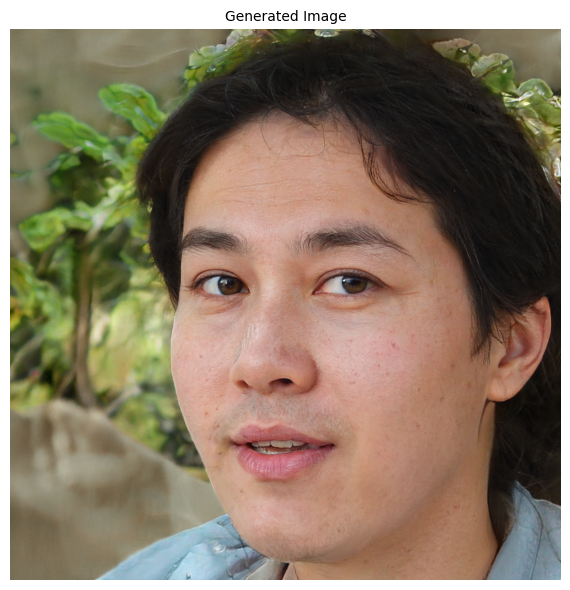

In [7]:
style_generator = StyleAffineMapper(mapping, affines)
style_synthesis = StyleSynthesisNetwork(G.synthesis)

z = torch.randn(1, 512).to(device)
styles = style_generator(z, truncation=0.5)
for i, style_vector in enumerate(styles):
    print(f"Style vector {i+1}: shape {style_vector.shape}")
generated_image = style_synthesis(styles)
print(generated_image.shape)
plot_tensor_images(generated_image, titles=["Generated Image"], cols=1, figsize=6)

In [8]:
with open('clip_data/imagenet_templates.json', 'r') as f:
    data = json.load(f)
    imagenet_templates = data['imagenet_templates']
    
def zeroshot_classifier(classnames, templates,model):
    '''get the CLIP text embedding for the given classnames'''
    with torch.no_grad():
        zeroshot_weights = []
        for classname in classnames:
            texts = [template.format(classname) for template in templates] # format the text(classname) with  templates to get average text embedding, which is more robust to different templates.
            texts = clip.tokenize(texts).cuda() #tokenize
            class_embeddings = model.encode_text(texts) #embed with text encoder
            class_embeddings /= class_embeddings.norm(dim=-1, keepdim=True)
            class_embedding = class_embeddings.mean(dim=0)
            class_embedding /= class_embedding.norm()
            zeroshot_weights.append(class_embedding)
        zeroshot_weights = torch.stack(zeroshot_weights, dim=1).cuda()
    return zeroshot_weights

def GetClipDirection(classnames,model):
    '''get the CLIP direction vector for the target - neutral class clip embeddings'''
    text_features=zeroshot_classifier(classnames, imagenet_templates,model).t()
    
    dt=text_features[0]-text_features[1]
    dt=dt.cpu().numpy()
    

    print(np.linalg.norm(dt))
    dt=dt/np.linalg.norm(dt)
    return dt

In [9]:
def SplitS(style_direction_flattened):
    start=0
    style_direction=[]

    mindexs = [0, 2, 3, 5, 6, 8, 9, 11, 12, 14, 15, 17, 18, 20, 21, 23, 24] # ingoring ToRGB layers
    style_shapes = [512] * 15 + [256] * 3 + [128] * 3 + [64] * 3 + [32] * 2
    
    for i in range(26):
        if i in mindexs:
            layer_len=style_shapes[i]
            end=start+layer_len
            style=style_direction_flattened[start:end]
            start=end
        else:
            style=np.zeros(style_shapes[i])
        style = torch.tensor(style)
        style_2d = style.unsqueeze(0)

        style_direction.append(style_2d.detach().clone().float().cuda())
    return style_direction

def GetStyleDirection(clip2styles_matrix,clip_direction,threshold):
    '''get the direction in the style space (boundary) with the precomputed clip2styles matrix.'''
    style_direction_flattened=np.dot(clip2styles_matrix,clip_direction) # project the CLIP direction to the style space with the precomputed clip2styles matrix, which is trained to map CLIP directions to style space directions.
    
    style_direction_flattened_2=copy.copy(style_direction_flattened)
    select=np.abs(style_direction_flattened)<threshold
    num_c=np.sum(~select)


    style_direction_flattened_2[select]=0 # apply threshold
    tmp=np.abs(style_direction_flattened_2).max()
    print('max value before normalization:',tmp)
    style_direction_flattened_2/= (tmp + 1e-5) # normalize
    
    style_direction=SplitS(style_direction_flattened_2) # split flattend style vector into different layers
    print('num of channels being manipulated:',num_c)
    return style_direction,num_c

def GetStyleDirectionModel(clip2styles_matrix,clip_direction,top_styles,clip2styles_model):
    '''get the direction in the style space (boundary) with the precomputed clip2styles matrix.'''
    style_direction_flattened = clip2styles_model(torch.tensor(clip_direction).float().cuda()) # project the CLIP direction to the style space with the precomputed clip2styles matrix, which is trained to map CLIP directions to style space directions.
    style_direction_flattened=style_direction_flattened.cpu().detach().numpy()
    style_direction_flattened_2=copy.copy(style_direction_flattened)
    threshold_idx = np.argsort(np.abs(style_direction_flattened))[:-int(top_styles)]
    select = np.zeros(len(style_direction_flattened), dtype=bool)
    select[threshold_idx] = True

    style_direction_flattened_2[select] = 0
    tmp=np.abs(style_direction_flattened_2).max()
    print('max value before normalization:',tmp)
    style_direction_flattened_2/= (tmp + 1e-5) # normalize
    
    style_direction=SplitS(style_direction_flattened_2) # split flattend style vector into different layers
    print('num of channels being manipulated:',top_styles)
    return style_direction

In [10]:
def CalcStyleVectors(style_vecs_initial, style_direction, alpha = 1): # 26, 512 || 
    '''Manipulate the style vectors by adding the boundary direction, and return the manipulated style vectors as a list'''
    style_vecs_manipulated= copy.deepcopy(style_vecs_initial)
    l=torch.tensor([[alpha]]).float().to(device) # manipulation strength for each step, shape = step

    assert len(style_vecs_manipulated) == len(style_direction)
    for i in range(len(style_direction)): # for each layer
        style_vecs_manipulated[i]+=l*style_direction[i] # manipulate the style vectors in the direction of style_direction with strength l
    
    return style_vecs_manipulated

# Define Clip2Style Mapper
Only run one of the cells.

In [11]:
class Clip2StyleMapper(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(512, 1024),
            torch.nn.ReLU(),
            torch.nn.Linear(1024, 2048),
            torch.nn.ReLU(),
            torch.nn.Linear(2048, 6048)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
class Clip2StyleMapper(torch.nn.Module):
    def __init__(self):
        super().__init__()       
        self.net = torch.nn.Sequential(torch.nn.Linear(512, 6048))

    def forward(self, x):
        return self.net(x)

# Generate inital style vectors

In [43]:
model, preprocess = clip.load("ViT-B/32", device=device, jit=False)

clip2styles_matrix = np.load("clip_data/clip2styles.npy")

z = torch.randn(1, 512).to(device)
style_vecs_initial = style_generator(z, truncation=0.5)


skin_latin_american 10.0 4.0
0.3218
max value before normalization: 0.20906934
num of channels being manipulated: 10.0


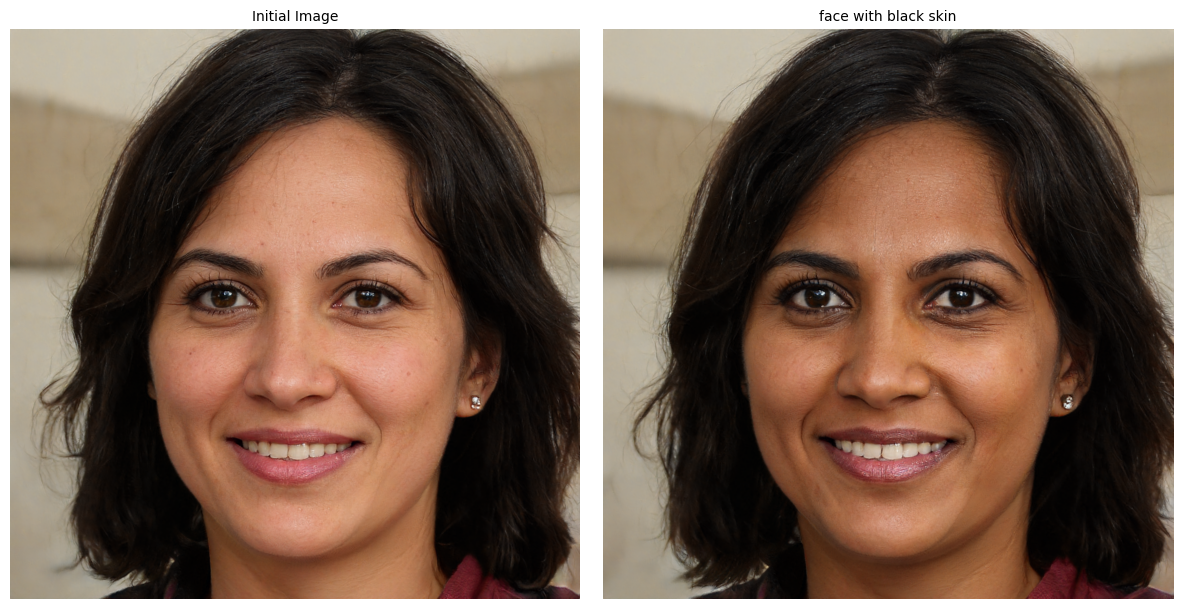

In [ ]:
prompts = np.array(
    [
        # ["age_20", "face of person", "face of a 20 year old person", 100, 4],
        # ["age_30", "face of person", "face of a 30 year old person", 100, 4],
        # ["age_40", "face of person", "face of a 40 year old person", 100, 4],
        # ["age_50", "face of person", "face of a 50 year old person", 100, 4],
        # ["age_60", "face of person", "face of a 60 year old person", 100, 4],
        # ["eye_blue", "face with black eyes", "face with blue eyes", 20, 4], # new
        # ["eye_brows_black", "face with eyebrows", "face with black eyebrows", 13, 4],
        # ["eye_brows_curved", "face with eyebrows", "face with curved eyebrows", 20, 4],
        # ["eye_brows_straight", "face with eyebrows", "face with straight eyebrows", 20, 4],
        # ["eye_brows_thick", "face with eyebrows", "face with thick eyebrows", 20, 10],
        # ["eye_brows_thin", "face with eyebrows", "face with thin eyebrows", 20, 4],
        # ["eye_brows_white", "face with cheeks", "face with fat cheeks", 20, 4], # new
        # ["eye_closed", "face with eyes", "face with closed eyes", 100, 4],
        # ["eye_green", "face with eyes", "face with green eyes", 20, 4], # new
        # ["beard", "fully shaved face", "face covered with full beard", 20, 6], # new
        # ["hair_black", "face with hair", "face with black hair", 5, 4],
        # ["hair_blonde", "face with hair", "face with blonde hair", 30, 4],
        # ["hair_bold", "face with hair", "face with without hair", 100, 10], # not working for female but works for male
        # ["hair_curly", "face with hair", "face with curly hair", 100, 4],
        # ["hair_long", "face with hair", "face with long hair", 30, 4],
        # ["hair_red", "face with hair", "face with red hair", 15, 4],
        # ["hair_short", "face with hair", "face with short hair", 20, 4],
        # ["hair_straight", "face with hair", "face with straight hair", 100, 4],
        # ["hair_white", "face with black hair", "face with white hair", 100, 4],
        # ["skinny_face", "face", "skinny face", 100, 4], # new
        # ["fat_face", "normal face", "fat face", 80, 4], # new
        # ["big_forehead", "face with normal forehead", "face with big forehead", 80, 4], # new
        # ["big_eyes", "face with eye", "face with big eyes", 20, 4], # new
        # ["messy_hair", "face with hair", "face with messy hair", 50, 4], # new
        # ["skin_african", "face with white skin", "face with black skin", 10, 4],
        # ["skin_asian", "face with black skin", "face with white skin", 20, 4],
        # ["skin_british", "face with black skin", "face with british skin tone", 20, 4],
        # ["skin_indian", "face with white skin", "face with black skin", 10, 4],
        # ["skin_irish", "face with black skin", "face with british skin tone", 20, 4],
        # ["skin_latin_american", "face with white skin", "face with black skin", 10, 4],
        # ["square_jaws", "face with normal lips", "face with big lips", 100, 4]
    ]
)

clip2styles_mapper = Clip2StyleMapper().to(device)
clip2styles_mapper.load_state_dict(torch.load('out/mapping_network_3layer_1stage_non_linear.pth'))

def ManipulateImages(classnames, model, clip2styles_matrix, style_vecs_initial, beta, alpha):
    clip_direction = GetClipDirection(
        classnames, model
    )  # Get the CLIP direction vector for the target - neutral classes

    style_direction = GetStyleDirectionModel(clip2styles_matrix, clip_direction, top_styles=beta, clip2styles_model=clip2styles_mapper) # Get the style space direction corresponding to the CLIP direction

    style_vecs_manipulated = CalcStyleVectors(style_vecs_initial, style_direction, alpha) # Manipulate the style vectors in the direction of the style_direction with the given alpha and beta | shape = layers, num_images, steps,  feature_dimensions

    return style_vecs_manipulated


for i in range(len(prompts)): # for each text prompt
    filename, neutral, target, beta, alpha = prompts[i]

    beta = np.float32(beta)
    alpha = np.float32(alpha)

    print()
    print(filename, beta, alpha)
    classnames = [target, neutral]

    style_vecs_manipulated = ManipulateImages(classnames, model, clip2styles_matrix, style_vecs_initial, beta, alpha)

    # Generate images and plot
    generated_image_initial = style_synthesis(style_vecs_initial)
    generated_image_manipulated = style_synthesis(style_vecs_manipulated)
    combined = [generated_image_initial, generated_image_manipulated]
    plot_tensor_images(combined, titles=["Initial Image", target], cols=2, figsize=6)

## Save CSVs

In [173]:
prompts = np.array(
    [
        ["age_20", "face of person", "face of a 20 year old person", 100, 4],
        ["age_30", "face of person", "face of a 30 year old person", 100, 4],
        ["age_40", "face of person", "face of a 40 year old person", 100, 4],
        ["age_50", "face of person", "face of a 50 year old person", 100, 4],
        ["age_60", "face of person", "face of a 60 year old person", 100, 4],
        ["eye_blue", "face with black eyes", "face with blue eyes", 20, 4], # new
        ["eye_brows_black", "face with eyebrows", "face with black eyebrows", 13, 4],
        ["eye_brows_curved", "face with eyebrows", "face with curved eyebrows", 20, 4],
        ["eye_brows_straight", "face with eyebrows", "face with straight eyebrows", 20, 4],
        ["eye_brows_thick", "face with eyebrows", "face with thick eyebrows", 20, 10],
        ["eye_brows_thin", "face with eyebrows", "face with thin eyebrows", 20, 4],
        ["eye_brows_white", "face with cheeks", "face with fat cheeks", 20, 4], # new
        ["eye_closed", "face with eyes", "face with closed eyes", 100, 4],
        ["eye_green", "face with eyes", "face with green eyes", 20, 4], # new
        ["beard", "fully shaved face", "face covered with full beard", 20, 6], # new
        ["hair_black", "face with hair", "face with black hair", 5, 4],
        ["hair_blonde", "face with hair", "face with blonde hair", 30, 4],
        ["hair_bold", "face with hair", "face with without hair", 100, 10], # not working for female but works for male
        ["hair_curly", "face with hair", "face with curly hair", 100, 4],
        ["hair_long", "face with hair", "face with long hair", 30, 4],
        ["hair_red", "face with hair", "face with red hair", 15, 4],
        ["hair_short", "face with hair", "face with short hair", 20, 4],
        ["hair_straight", "face with hair", "face with straight hair", 100, 4],
        ["hair_white", "face with black hair", "face with white hair", 100, 4],
        ["skinny_face", "face", "skinny face", 100, 4], # new
        ["fat_face", "normal face", "fat face", 80, 4], # new
        ["big_forehead", "face with normal forehead", "face with big forehead", 80, 4], # new
        ["big_eyes", "face with eye", "face with big eyes", 20, 4], # new
        ["messy_hair", "face with hair", "face with messy hair", 50, 4], # new
        ["skin_african", "face with white skin", "face with black skin", 10, 4],
        ["skin_asian", "face with black skin", "face with white skin", 20, 4],
        ["skin_british", "face with black skin", "face with british skin tone", 20, 4],
        ["skin_indian", "face with white skin", "face with black skin", 10, 4],
        ["skin_irish", "face with black skin", "face with british skin tone", 20, 4],
        ["skin_latin_american", "face with white skin", "face with black skin", 10, 4]
    ]
)

clip2styles_mapper = Clip2StyleMapper().to(device)
clip2styles_mapper.load_state_dict(torch.load('out/mapping_network_3layer_1stage_non_linear.pth'))

def GetStyleDirections(classnames, model, clip2styles_matrix, style_vecs_initial, beta, alpha):
    clip_direction = GetClipDirection(
        classnames, model
    )  # Get the CLIP direction vector for the target - neutral classes

    style_direction = GetStyleDirectionModel(clip2styles_matrix, clip_direction, top_styles=beta, clip2styles_model=clip2styles_mapper) # Get the style space direction corresponding to the CLIP direction
    
    return style_direction

for i in range(len(prompts)): # for each text prompt
    filename, neutral, target, beta, alpha = prompts[i]

    beta = np.float32(beta)
    alpha = np.float32(alpha)

    print()
    print(filename, beta, alpha)
    classnames = [target, neutral]

    style_direction = GetStyleDirections(classnames, model, clip2styles_matrix, style_vecs_initial, beta, alpha)
    flat_style_direction = np.concatenate([s.cpu().detach().numpy().flatten() for s in style_direction])
    np.savetxt(f"csv/{filename}_style_vector.csv", [flat_style_direction], delimiter=",")


age_20 100.0 4.0
0.289
max value before normalization: 0.22254415
num of channels being manipulated: 100.0

age_30 100.0 4.0
0.2754
max value before normalization: 0.20159087
num of channels being manipulated: 100.0

age_40 100.0 4.0
0.2905
max value before normalization: 0.21997076
num of channels being manipulated: 100.0

age_50 100.0 4.0
0.2957
max value before normalization: 0.23964341
num of channels being manipulated: 100.0

age_60 100.0 4.0
0.3032
max value before normalization: 0.23397069
num of channels being manipulated: 100.0

eye_blue 20.0 4.0
0.4158
max value before normalization: 0.23467213
num of channels being manipulated: 20.0

eye_brows_black 13.0 4.0
0.2258
max value before normalization: 0.17931636
num of channels being manipulated: 13.0

eye_brows_curved 20.0 4.0
0.1624
max value before normalization: 0.18532221
num of channels being manipulated: 20.0

eye_brows_straight 20.0 4.0
0.175
max value before normalization: 0.18092263
num of channels being manipulated: 2

0.4783
max value before normalization: 0.3304512
num of channels being manipulated: 165
Prompt:  male face with blue eyes.


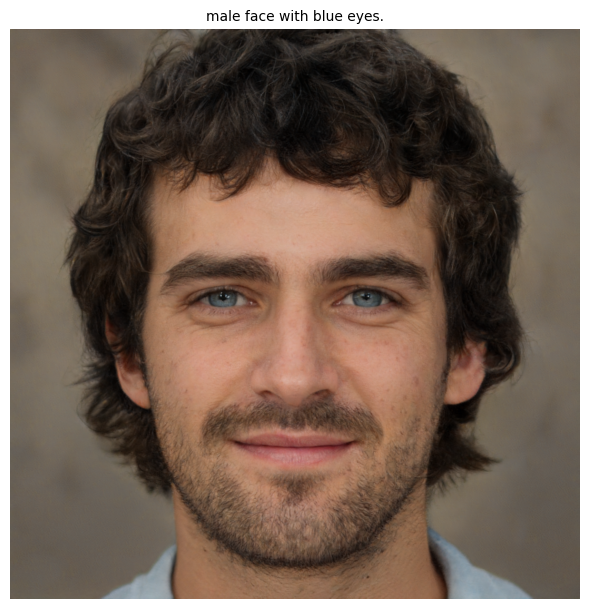

In [ ]:
z = torch.zeros(1, 512).to(device)
style_vecs_avg = style_generator(z, truncation=0.5)

filename = "init"
neutral = "female face with eyes"

image_prompt = "male face with blue eyes."
beta, alpha = 100, 3

style_vecs_start = ManipulateImages([image_prompt, neutral], model, clip2styles_matrix, style_vecs_avg, beta, alpha)
generated_image_start = style_synthesis(style_vecs_start)

print("Prompt: ",image_prompt)
plot_tensor_images(generated_image_start, titles=[image_prompt], cols=2, figsize=6)

# Helper function

In [ ]:
def GetClipDirections(clip_embeddings):
    '''clip_embeddings = [target_embedding_tensor, neutral_embedding_tensor] each [batch, 512]'''
    target = clip_embeddings[0]
    neutral = clip_embeddings[1]

    target = target / (target.norm(dim=1, keepdim=True) + 1e-8)
    neutral = neutral / (neutral.norm(dim=1, keepdim=True) + 1e-8)

    clip_directions = target - neutral

    clip_directions = clip_directions / (clip_directions.norm(dim=1, keepdim=True) + 1e-8)

    return clip_directions[0].cpu().detach().numpy()

# Text to image with average image

C:\Users\kbras\AppData\Local\Temp\ipykernel_23060\1184817810.py:42: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  style_direction_flattened = clip2styles_model(torch.tensor(clip_direction).float().cuda()) # project the CLIP direction to the style space with the precomputed clip2styles matrix, which is trained to map CLIP directions to style space directions.


max value before normalization: 0.3175386
num of channels being manipulated: 38
Prompt:  portrait image of an adult male face with blue eyes.


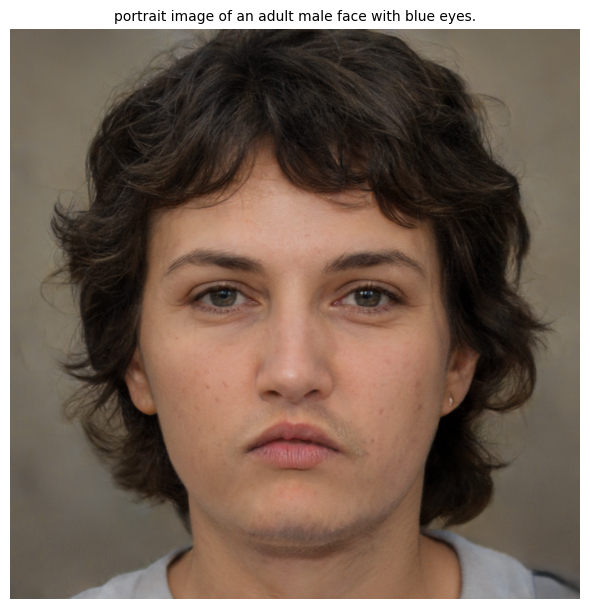

In [53]:
z = torch.zeros(1, 512).to(device)
style_vecs_avg = style_generator(z, truncation=0.5)
image_avg = style_synthesis(style_vecs_avg)
image_avg_resized = F.interpolate(image_avg, size=(224, 224), mode='bicubic', align_corners=False)

filename = "init"
neutral = "female face with eyes"

image_prompt = "portrait image of an adult male face with blue eyes."
beta, alpha = 0.25, 4

text_features = zeroshot_classifier([image_prompt, neutral], imagenet_templates,model).t()
image_embedding = model.encode_image(image_avg_resized).float()  # shape [1, 512]
image_embedding /= image_embedding.norm(dim=-1, keepdim=True)

clip2styles_mapper = Clip2StyleMapper().to(device)
clip2styles_mapper.load_state_dict(torch.load('out/mapping_network_3layer_1stage_non_linear.pth'))

clip_direction = GetClipDirections([text_features[0].unsqueeze(0), image_embedding]) # Get the CLIP direction vector for the target - neutral classes

style_direction, num_c = GetStyleDirection(clip2styles_matrix, clip_direction, threshold=beta) # Get the style space direction corresponding to the CLIP direction

style_vecs_start = CalcStyleVectors(style_vecs_avg, style_direction, alpha) # Manipulate the style vectors in the direction of the style_direction with the given alpha and beta | shape = layers, num_images, steps,  feature_dimensions

generated_image_start = style_synthesis(style_vecs_start)

print("Prompt: ",image_prompt)
plot_tensor_images(generated_image_start, titles=[image_prompt], cols=2, figsize=6)

# Text to image with image and text embeddings

In [42]:
pil_img = Image.open("images/source1.jpg").convert("RGB").resize((224, 224))
img_np = np.array(pil_img)                                  # H, W, C  uint8 [0, 255]
source1 = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).float()  # 1, C, H, W
source1 = (source1 - 127.5) / 127.5                         # scale to [-1, 1] (matches plot_tensor_images)
source1 = source1.to(device)
print(source1.shape, source1.dtype, source1.min().item(), source1.max().item())

torch.Size([1, 3, 224, 224]) torch.float32 -0.8823529481887817 1.0


shape torch.Size([1, 3, 224, 224])
shape torch.Size([1, 3, 224, 224])
max value before normalization: 0.37175024
num of channels being manipulated: 5198
Prompt:  portrait image of an adult male face with blue eyes.


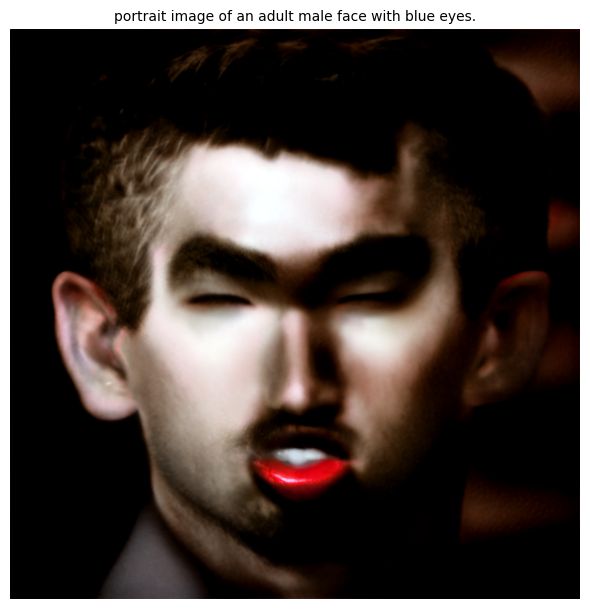

In [ ]:
z = torch.zeros(1, 512).to(device)
style_vecs_avg = style_generator(z, truncation=0.5)
image_avg = style_synthesis(style_vecs_avg)
image_avg_resized = F.interpolate(image_avg, size=(224, 224), mode='bicubic', align_corners=False)

filename = "init"
neutral = "female face with eyes"

image_prompt = "portrait image of an adult male face with blue eyes."
beta, alpha = 0.1, 4

print("shape", image_avg_resized.shape)
print("shape", source1.shape)

text_features = zeroshot_classifier([image_prompt, neutral], imagenet_templates,model).t()
image_embedding = model.encode_image(image_avg_resized).float()  # shape [1, 512]
image_embedding /= image_embedding.norm(dim=-1, keepdim=True)
image_embedding_source1 = model.encode_image(source1).float()  # shape [1, 512]
image_embedding_source1 /= image_embedding_source1.norm(dim=-1, keepdim=True)

clip_direction = GetClipDirections([image_embedding_source1, image_embedding]) # Get the CLIP direction vector for the target - neutral classes

style_direction, num_c = GetStyleDirection(clip2styles_matrix, clip_direction, threshold=beta) # Get the style space direction corresponding to the CLIP direction

style_vecs_start = CalcStyleVectors(style_vecs_avg, style_direction, alpha) # Manipulate the style vectors in the direction of the style_direction with the given alpha and beta | shape = layers, num_images, steps,  feature_dimensions

generated_image_start = style_synthesis(style_vecs_start)

print("Prompt: ",image_prompt)
plot_tensor_images(generated_image_start, titles=[image_prompt], cols=2, figsize=6)